Transformer Berbasis Sequence-to-Sequence untuk Klasifikasi Sinyal EKG dalam Deteksi Aritmia (Input Sinyal)

0. Import & Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import numpy as np
import wfdb
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import resample
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)


1. Konfigurasi Dasar

In [3]:
FS = 250
WINDOW = 2000
EPOCHS = 30
BATCH = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_DIR = "/content/drive/MyDrive/Data TA"


2. Label Mapping

In [4]:
LABEL_MAP_MITDB = {
    "N": 0,      # Normal
    "V": 1      # Ventricular ectopic beat
}


In [ ]:
LABEL_MAP_AFDB = {
    "N": 0,      # Normal
    "AFIB": 1   # Atrial Fibrillation
}


In [ ]:
LABEL_MAP_VFDB = {
    "VF": 0,      # Ventricular Fibrillation
    "VT": 1     # Ventricular Tachycardia
}


3. Fungsi Umum

In [5]:
def normalize(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-8)


4. Load MITDB (Beat Classification)

In [6]:
def load_mitdb():
    X, y = [], []
    path = f"{BASE_DIR}/mit-bih-arrhythmia-database-1.0.0"

    for rec in os.listdir(path):
        if not rec.endswith(".dat"): continue

        r = wfdb.rdrecord(os.path.join(path, rec[:-4]))
        a = wfdb.rdann(os.path.join(path, rec[:-4]), "atr")

        sig = r.p_signal[:,0]
        fs = int(r.fs)
        if fs != FS:
            sig = resample(sig, int(len(sig)*FS/fs))

        for s, sym in zip(a.sample, a.symbol):
            if sym not in LABEL_MAP_MITDB: continue

            idx = int(s * FS / fs)
            if idx-WINDOW//2 < 0 or idx+WINDOW//2 > len(sig): continue

            seg = normalize(sig[idx-WINDOW//2:idx+WINDOW//2])
            X.append(seg)
            y.append(LABEL_MAP_MITDB[sym])

    return np.array(X), np.array(y)


5. Load AFDB (Rhythm)

In [7]:
def load_afdb():
    X, y = [], []
    path = f"{BASE_DIR}/files"

    for rec in os.listdir(path):
        if not rec.endswith(".dat"): continue

        sig, fields = wfdb.rdsamp(os.path.join(path, rec[:-4]))
        ann = wfdb.rdann(os.path.join(path, rec[:-4]), "atr")

        signal = sig[:,0]
        fs = int(fields["fs"])
        if fs != FS:
            signal = resample(signal, int(len(signal)*FS/fs))

        for i in range(len(ann.sample)-1):
            label = ann.aux_note[i].strip("(")
            if label not in LABEL_MAP_AFDB: continue

            start = int(ann.sample[i]*FS/fs)
            if start+WINDOW > len(signal): continue

            seg = normalize(signal[start:start+WINDOW])
            X.append(seg)
            y.append(LABEL_MAP_AFDB[label])

    return np.array(X), np.array(y)


6. Load VFDB

In [8]:
def load_vfdb():
    X, y = [], []
    path = f"{BASE_DIR}/mit-bih-malignant-ventricular-ectopy-database-1.0.0"

    for rec in os.listdir(path):
        if not rec.endswith(".dat"):
            continue

        record = rec.replace(".dat", "")

        try:
            sig, fields = wfdb.rdsamp(os.path.join(path, record))
            ann = wfdb.rdann(os.path.join(path, record), "atr")
        except Exception as e:
            print("Skip:", record, e)
            continue

        fs = int(fields["fs"])
        signal = sig[:, 0]

        if fs != FS:
            signal = resample(signal, int(len(signal) * FS / fs))

        for i, label in enumerate(ann.aux_note):

            label = label.strip().upper()

            if "VF" in label:
                cls = 0
            elif "VT" in label:
                cls = 1
            else:
                continue

            idx = int(ann.sample[i] * 250 / fs)

            if idx - WINDOW//2 < 0 or idx + WINDOW//2 > len(signal):
                continue

            segment = signal[idx - WINDOW//2 : idx + WINDOW//2]
            X.append(segment)
            y.append(cls)

    return np.array(X), np.array(y)


7. Balancing

In [9]:
def balance_classes(X, y):
    classes, counts = np.unique(y, return_counts=True)
    min_count = counts.min()

    Xb, yb = [], []
    for c in classes:
        idx = np.where(y == c)[0][:min_count]
        Xb.append(X[idx])
        yb.append(y[idx])

    Xb = np.concatenate(Xb)
    yb = np.concatenate(yb)

    perm = np.random.permutation(len(yb))
    return Xb[perm], yb[perm]


8. Samples Checking

In [10]:
# MITDB

X_mit, y_mit = load_mitdb()
print("Before balance:", np.unique(y_mit, return_counts=True))

X_mit, y_mit = balance_classes(X_mit, y_mit)

print("After balance:", np.unique(y_mit, return_counts=True))



Before balance: (array([0, 1]), array([74708,  7106]))
After balance: (array([0, 1]), array([7106, 7106]))


In [11]:
# AFDB

X_af, y_af = load_afdb()
print("Before balance:", np.unique(y_af, return_counts=True))

X_af, y_af = balance_classes(X_af, y_af)

print("After balance:", np.unique(y_af, return_counts=True))



Before balance: (array([0, 1]), array([274, 283]))
After balance: (array([0, 1]), array([274, 274]))


In [12]:
# VFDB

X_vf, y_vf = load_vfdb()
print("Before balance:", np.unique(y_vf, return_counts=True))

X_vf, y_vf = balance_classes(X_vf, y_vf)

print("After balance:", np.unique(y_vf, return_counts=True))



Before balance: (array([0, 1]), array([111,  98]))
After balance: (array([0, 1]), array([98, 98]))


9. Dataset & Loader

In [13]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


10. Model (Seq2Seq Transformer)

In [14]:
class ECGSeq2Seq(nn.Module):
    def __init__(self, n_class):
        super().__init__()

        # CNN 1D feature extractor
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        # 2000 → 500 length, channel 64
        self.proj = nn.Linear(64, 128)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=4,
            batch_first=True
        )

        self.enc = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(128, n_class)

    def forward(self, x):
        # x: (batch, 2000)
        x = x.unsqueeze(1)          # (batch, 1, 2000)
        x = self.cnn(x)             # (batch, 64, 500)
        x = x.permute(0, 2, 1)      # (batch, 500, 64)
        x = self.proj(x)            # (batch, 500, 128)
        x = self.enc(x)             # (batch, 500, 128)
        x = x.mean(dim=1)           # global average pooling
        return self.fc(x)


11. Train + Evaluation

In [15]:
def train_and_evaluate(X, y, title):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y)

    train_loader = DataLoader(ECGDataset(Xtr,ytr), BATCH, True)
    test_loader  = DataLoader(ECGDataset(Xte,yte), BATCH)

    model = ECGSeq2Seq(len(np.unique(y))).to(DEVICE)

    if title == "MITDB":
        lr = 1e-4
    elif title == "AFDB":
        lr = 5e-5
    else:  # VFDB
        lr = 1e-5

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )


    loss_fn = nn.CrossEntropyLoss()

    for _ in range(EPOCHS):
        model.train()
        for xb,yb in train_loader:
            xb,yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()

    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for xb,yb in test_loader:
            xb = xb.to(DEVICE)
            out = model(xb)

            prob = torch.softmax(out, dim=1)
            pred = torch.argmax(prob, dim=1)

            y_true.extend(yb.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(prob[:, 1].cpu().numpy())

    acc = accuracy_score(y_true,y_pred)
    rec = recall_score(y_true,y_pred,average="macro")
    f1  = f1_score(y_true,y_pred,average="macro")
    spec = recall_score(y_true,y_pred,average="macro")
    auc = roc_auc_score(y_true, np.array(y_prob), multi_class="ovr")

    print(f"\n=== {title} ===")
    print(f"Accuracy     : {acc:.4f}")
    print(f"Recall       : {rec:.4f}")
    print(f"F1-score     : {f1:.4f}")
    print(f"Specificity  : {spec:.4f}")
    print(f"ROC-AUC      : {auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{title} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()



=== MITDB ===
Accuracy     : 0.9954
Recall       : 0.9954
F1-score     : 0.9954
Specificity  : 0.9954
ROC-AUC      : 0.9999


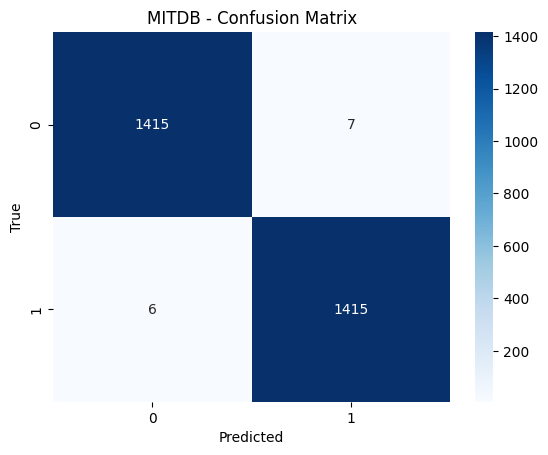


=== AFDB ===
Accuracy     : 0.8364
Recall       : 0.8364
F1-score     : 0.8337
Specificity  : 0.8364
ROC-AUC      : 0.8916


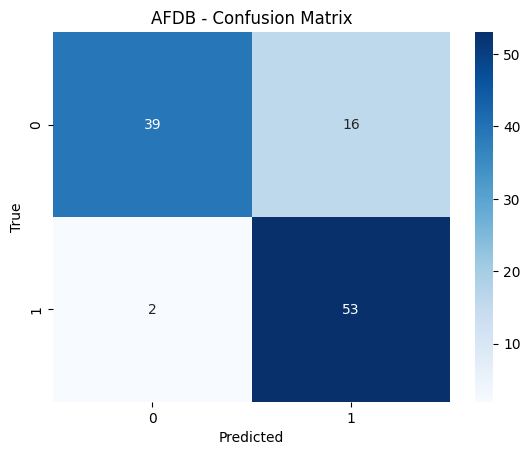


=== VFDB ===
Accuracy     : 0.9250
Recall       : 0.9250
F1-score     : 0.9250
Specificity  : 0.9250
ROC-AUC      : 0.9450


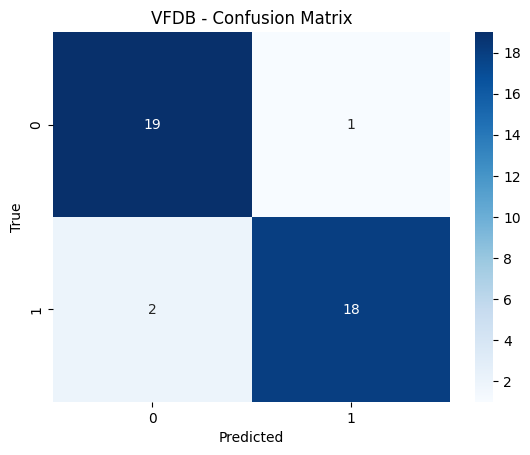

In [16]:
# MITDB

X_mit, y_mit = load_mitdb()
X_mit, y_mit = balance_classes(X_mit, y_mit)
train_and_evaluate(X_mit, y_mit, "MITDB")

# AFDB

X_af, y_af = load_afdb()
X_af, y_af = balance_classes(X_af, y_af)
train_and_evaluate(X_af, y_af, "AFDB")

# VFDB

X_vf, y_vf = load_vfdb()
X_vf, y_vf = balance_classes(X_vf, y_vf)
train_and_evaluate(X_vf, y_vf, "VFDB")
